In [4]:
import h5py
import pandas as pd
import os

ICB_ORIG = "/beegfs/home/iruizdealda/HCC_singlecell_project/data/ICB_dataset/134d34af-cbcd-4837-9310-3d1f83ec6f18.h5ad"

# Leer solo los metadatos (obs) sin cargar la matriz X
with h5py.File(ICB_ORIG, "r") as f:
    print("Claves principales del fichero:")
    print(list(f.keys()))
    print("\nColumnas en obs:")
    print(list(f["obs"].keys()))

Claves principales del fichero:
['X', 'layers', 'obs', 'obsm', 'obsp', 'raw', 'uns', 'var', 'varm', 'varp']

Columnas en obs:
['Cancer_type_update', 'Cell_type_broad', 'Combined_outcome', 'PMID', 'PMID_donor_id', 'Primary_or_met', 'Sample', 'Study_name', 'Study_name_cancer', 'Treatment.or.Mode.of.Action', '_index', 'assay', 'assay_ontology_term_id', 'author_cell_type', 'author_cell_type_update', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'donor_id_cell_types', 'donor_id_cell_types_pre_post', 'donor_id_outcome', 'donor_id_pre_post', 'donor_id_pre_post_outcome', 'is_primary_data', 'nCount_RNA', 'nFeature_RNA', 'observation_joinid', 'outcome', 'pre_post', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type']


In [5]:
import h5py
import pandas as pd
import numpy as np

ICB_ORIG = "/beegfs/home/iruizdealda/HCC_singlecell_project/data/ICB_dataset/134d34af-cbcd-4837-9310-3d1f83ec6f18.h5ad"
DATA_DIR = "/beegfs/home/iruizdealda/HCC_singlecell_project/data"

# Leer solo obs sin cargar X
with h5py.File(ICB_ORIG, "r") as f:
    # Leer columnas de interés
    cancer_type     = pd.Categorical.from_codes(
                        f["obs"]["Cancer_type_update"]["codes"][:],
                        f["obs"]["Cancer_type_update"]["categories"][:].astype(str))
    cell_broad      = pd.Categorical.from_codes(
                        f["obs"]["Cell_type_broad"]["codes"][:],
                        f["obs"]["Cell_type_broad"]["categories"][:].astype(str))
    author_celltype = pd.Categorical.from_codes(
                        f["obs"]["author_cell_type"]["codes"][:],
                        f["obs"]["author_cell_type"]["categories"][:].astype(str))
    cell_type_onto  = pd.Categorical.from_codes(
                        f["obs"]["cell_type"]["codes"][:],
                        f["obs"]["cell_type"]["categories"][:].astype(str))
    index           = f["obs"]["_index"][:].astype(str)

obs_df = pd.DataFrame({
    "Cancer_type_update": cancer_type,
    "Cell_type_broad":    cell_broad,
    "author_cell_type":   author_celltype,
    "cell_type":          cell_type_onto,
}, index=index)

print("Tipos de cáncer disponibles:")
print(obs_df["Cancer_type_update"].value_counts())


Tipos de cáncer disponibles:
Cancer_type_update
TNBC     113033
ER+       87648
BCC       76529
ccRCC     29993
HER2+     16017
Mel       13141
MBM       10895
iCCA       5433
HCC        3252
Name: count, dtype: int64


In [6]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

FIGURES_DIR = "/beegfs/home/iruizdealda/HCC_singlecell_project/figures/crossval_ICB"
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Filtrar solo HCC del fichero original ──────────────────
obs_hcc = obs_df[obs_df["Cancer_type_update"] == "HCC"].copy()
print(f"Células HCC en original: {len(obs_hcc)}")

print("\nCell_type_broad (original):")
print(obs_hcc["Cell_type_broad"].value_counts())

print("\nauthor_cell_type (original):")
print(obs_hcc["author_cell_type"].value_counts())

# ── Cargar tu fichero anotado por KNN ──────────────────────
adata_knn = sc.read_h5ad(os.path.join(DATA_DIR, "adata_ICB_HCC_raw.h5ad"))
print(f"\nCélulas en KNN anotado: {adata_knn.n_obs}")

print("\nTus etiquetas KNN (celltype):")
print(adata_knn.obs["celltype"].value_counts())

# ── Alinear índices ────────────────────────────────────────
# Células comunes entre ambos ficheros
cells_comunes = obs_hcc.index.intersection(adata_knn.obs_names)
print(f"\nCélulas comunes (índices coincidentes): {len(cells_comunes)}")


Células HCC en original: 3252

Cell_type_broad (original):
Cell_type_broad
Other        2509
Malignant     743
Name: count, dtype: int64

author_cell_type (original):
author_cell_type
NA                                               743
TEC                                              738
T cell                                           586
CAF                                              506
B cell                                           287
TAM                                              278
HPC-like                                          94
unclassified                                      20
NK_cells                                           0
Naive                                              0
Normal Tissue                                      0
Plasma_cells                                       0
T Cell                                             0
T.CD4                                              0
T.CD8                                              0
T.cell               

Células con anotación original válida: 2509
(Excluidas 743 células malignas sin tipo en original)

Distribución tras mapeo:
Original_mapped
Endothelial     738
T/NK            586
Fibroblast      506
B               287
Myeloid         278
Hepatocyte       94
unclassified     20
Name: count, dtype: int64


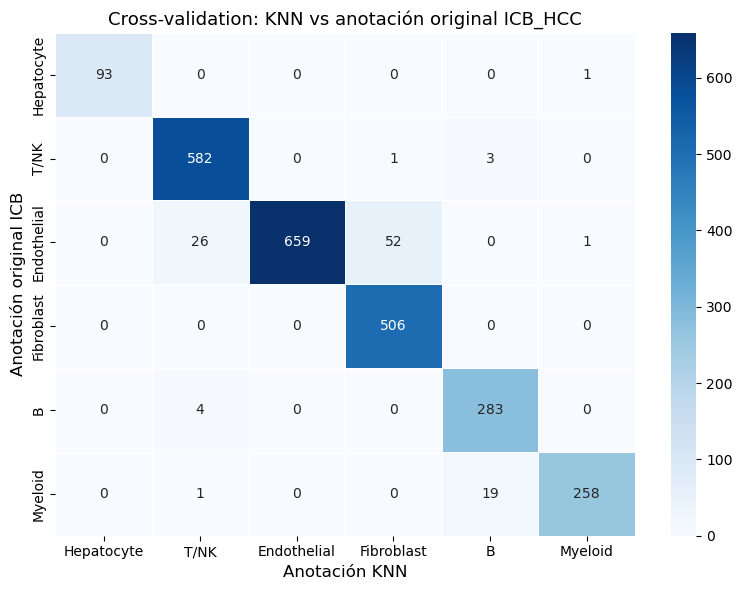

Guardada matriz de confusión en: /beegfs/home/iruizdealda/HCC_singlecell_project/figures/crossval_ICB

Classification report:
              precision    recall  f1-score   support

  Hepatocyte       1.00      0.99      0.99        94
        T/NK       0.93      0.99      0.96       586
 Endothelial       1.00      0.89      0.94       738
  Fibroblast       0.90      1.00      0.95       506
           B       0.93      0.99      0.96       287
     Myeloid       0.99      0.93      0.96       278

   micro avg       0.95      0.96      0.95      2489
   macro avg       0.96      0.96      0.96      2489
weighted avg       0.95      0.96      0.95      2489

UMAP guardado en: /beegfs/home/iruizdealda/HCC_singlecell_project/figures/crossval_ICB


In [9]:
# ── Construir DataFrame comparativo ────────────────────────
df_comp = pd.DataFrame({
    "KNN":      adata_knn.obs.loc[cells_comunes, "celltype"].values,
    "Original": obs_hcc.loc[cells_comunes, "author_cell_type"].values
})

# Quedarnos solo con las células que tienen anotación original real
# (excluir NA que son las células malignas sin tipo asignado)
df_comp_valido = df_comp[df_comp["Original"] != "NA"].copy()
print(f"Células con anotación original válida: {len(df_comp_valido)}")
print(f"(Excluidas {len(df_comp) - len(df_comp_valido)} células malignas sin tipo en original)\n")

# ── Mapeo entre nomenclaturas ───────────────────────────────
mapeo_orig = {
    "T cell":       "T/NK",
    "TEC":          "Endothelial",
    "CAF":          "Fibroblast",
    "B cell":       "B",
    "TAM":          "Myeloid",
    "HPC-like":     "Hepatocyte",
    "unclassified": "unclassified",
}

df_comp_valido["Original_mapped"] = df_comp_valido["Original"].map(mapeo_orig).fillna("Other")
print("Distribución tras mapeo:")
print(df_comp_valido["Original_mapped"].value_counts())

# ── Matriz de confusión ─────────────────────────────────────
labels = ["Hepatocyte", "T/NK", "Endothelial", "Fibroblast", "B", "Myeloid"]

cm = confusion_matrix(
    df_comp_valido["Original_mapped"],
    df_comp_valido["KNN"],
    labels=labels
)

cm_df = pd.DataFrame(cm, index=labels, columns=labels)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax,
    linewidths=0.5
)
ax.set_xlabel("Anotación KNN", fontsize=12)
ax.set_ylabel("Anotación original ICB", fontsize=12)
ax.set_title("Cross-validation: KNN vs anotación original ICB_HCC", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "confusion_matrix_ICB_crossval.png"), dpi=200)
plt.show()
plt.close()
print(f"Guardada matriz de confusión en: {FIGURES_DIR}")

# ── Métricas ────────────────────────────────────────────────
print("\nClassification report:")
print(classification_report(
    df_comp_valido["Original_mapped"],
    df_comp_valido["KNN"],
    labels=labels,
    zero_division=0
))

# ── UMAP lado a lado ────────────────────────────────────────
# Añadir anotación original mapeada al objeto KNN
adata_knn.obs["celltype_ICB_original"] = (
    df_comp["Original"].map(mapeo_orig).fillna("Malignant").values
)

# Forzar que scanpy guarde en FIGURES_DIR
sc.settings.figdir = FIGURES_DIR

sc.pl.umap(
    adata_knn,
    color=["celltype", "celltype_ICB_original"],
    ncols=2,
    title=["Anotación KNN (tuya)", "Anotación original ICB"],
    save="_ICB_crossval_umap.png",
    show=False
)
plt.close()
print(f"UMAP guardado en: {FIGURES_DIR}")